<a href="https://colab.research.google.com/github/h3it-dias/NLP_Group_Gradientes_Backpropagation/blob/main/notebooks/Embeddings_Gradientes_Simples.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Embeddings e Gradientes (versão simplificada, para aula)

Versão enxuta do notebook `Embeddings_Gradientes.ipynb`, pensada pra
apresentar pra uma turma: usa `nn.Linear` e `nn.Embedding` normais (em vez
de decompor cada multiplicação escalar por escalar), então o código fica
bem mais parecido com o que vocês vão escrever no dia a dia. Em troca, o
diagrama do grafo mostra a **estrutura** das operações (shapes, nomes das
funções de backward), não o valor exato de cada peso — mas a ideia por
trás de `.grad` e `.backward()` é a mesma.

In [1]:
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchviz import make_dot

torch.manual_seed(0)

## Vocabulário e corpus

In [2]:
from collections import Counter

UNK_TOKEN = "<unk>"

TOY_CORPUS = [
    "o gato preto dorme no sofa",
    "o cachorro marrom corre no parque",
    "o gato branco brinca com o cachorro",
    "o cachorro late para o gato",
    "o gato mia para o cachorro",
    "a crianca brinca com o cachorro no parque",
    "a crianca brinca com o gato no sofa",
]


def tokenize(text):
    return text.lower().split()


class Vocab:
    def __init__(self, tokens):
        counts = Counter(tokens)
        self.itos = [UNK_TOKEN] + sorted(counts, key=lambda tok: (-counts[tok], tok))
        self.stoi = {tok: i for i, tok in enumerate(self.itos)}

    def __len__(self):
        return len(self.itos)

    def encode(self, token):
        return self.stoi.get(token, self.stoi[UNK_TOKEN])

    def decode(self, index):
        return self.itos[index]


def build_vocab(corpus):
    tokens = [tok for line in corpus for tok in tokenize(line)]
    return Vocab(tokens)


def nearest_neighbors(word, vocab, weights, top_k=5):
    idx = vocab.encode(word)
    sims = F.cosine_similarity(weights, weights[idx].unsqueeze(0))
    top = torch.topk(sims, min(top_k + 1, len(vocab)))
    results = []
    for score, i in zip(top.values.tolist(), top.indices.tolist()):
        if i != idx:
            results.append((vocab.decode(i), round(score, 4)))
    return results[:top_k]

## Classificador de sentimento

`nn.EmbeddingBag` faz o lookup e a média das palavras de uma frase de uma
vez só; um `nn.Linear` classifica o resultado como positivo/negativo.

In [3]:
POSITIVE = [
    "eu amo esse filme",
    "o dia esta lindo hoje",
    "que comida deliciosa",
    "estou muito feliz",
    "isso foi otimo",
]
NEGATIVE = [
    "eu odeio esse filme",
    "o dia esta horrivel hoje",
    "que comida horrivel",
    "estou muito triste",
    "isso foi pessimo",
]


class SentimentClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_classes=2):
        super().__init__()
        self.embedding = nn.EmbeddingBag(vocab_size, embedding_dim, mode="mean")
        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward(self, tokens, offsets):
        return self.classifier(self.embedding(tokens, offsets))


def encode_dataset(sentences, vocab):
    tokens, offsets = [], [0]
    for sentence in sentences:
        ids = [vocab.encode(tok) for tok in tokenize(sentence)]
        tokens.extend(ids)
        offsets.append(offsets[-1] + len(ids))
    return torch.tensor(tokens), torch.tensor(offsets[:-1])


def train(model, tokens, offsets, labels, epochs=200, lr=0.1):
    """Loop de treino padrão: forward, loss, backward, step. Reaproveitado
    depois pra comparar inicialização aleatória vs. pré-treinada."""
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    losses = []
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()
        logits = model(tokens, offsets)
        loss = F.cross_entropy(logits, labels)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

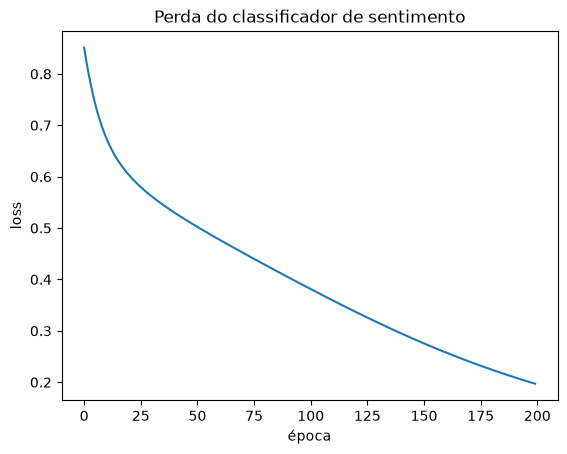

In [4]:
sentiment_sentences = POSITIVE + NEGATIVE
sentiment_labels = torch.tensor([1] * len(POSITIVE) + [0] * len(NEGATIVE))
sentiment_vocab = build_vocab(sentiment_sentences)
sentiment_tokens, sentiment_offsets = encode_dataset(sentiment_sentences, sentiment_vocab)

sentiment_model = SentimentClassifier(len(sentiment_vocab), embedding_dim=16)
losses = train(sentiment_model, sentiment_tokens, sentiment_offsets, sentiment_labels)

plt.plot(losses)
plt.xlabel("época")
plt.ylabel("loss")
plt.title("Perda do classificador de sentimento")
plt.show()

In [5]:
test_sentences = ["eu amo esse dia", "isso foi horrivel"]
tokens, offsets = encode_dataset(test_sentences, sentiment_vocab)
preds = sentiment_model(tokens, offsets).argmax(dim=1)
for sentence, pred in zip(test_sentences, preds):
    print(f'"{sentence}" -> {"positivo" if pred.item() == 1 else "negativo"}')

"eu amo esse dia" -> positivo
"isso foi horrivel" -> negativo


## Word2Vec: CBOW e Skip-gram

**CBOW** prediz a palavra central a partir do contexto ao redor.
**Skip-gram** faz o inverso: prediz o contexto a partir da palavra central.

In [6]:
class CBOWModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.linear = nn.Linear(embedding_dim, vocab_size)

    def forward(self, context):
        return self.linear(self.embeddings(context).mean(dim=1))


def make_cbow_pairs(corpus, vocab, window=2):
    pairs = []
    for line in corpus:
        tokens = [vocab.encode(tok) for tok in tokenize(line)]
        for i, center in enumerate(tokens):
            context = tokens[max(0, i - window):i] + tokens[i + 1:i + window + 1]
            if len(context) == 2 * window:
                pairs.append((context, center))
    return pairs


def train_cbow(corpus=TOY_CORPUS, epochs=300, embedding_dim=16, window=2, lr=0.05):
    vocab = build_vocab(corpus)
    pairs = make_cbow_pairs(corpus, vocab, window)
    contexts = torch.tensor([p[0] for p in pairs])
    centers = torch.tensor([p[1] for p in pairs])

    model = CBOWModel(len(vocab), embedding_dim)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    for epoch in range(epochs):
        optimizer.zero_grad()
        loss = F.cross_entropy(model(contexts), centers)
        loss.backward()
        optimizer.step()

    return model, vocab


cbow_model, cbow_vocab = train_cbow()
for word in ["gato", "cachorro"]:
    print(f"vizinhos de '{word}': {nearest_neighbors(word, cbow_vocab, cbow_model.embeddings.weight.detach())}")

vizinhos de 'gato': [('late', 0.4678), ('<unk>', 0.3242), ('mia', 0.2955), ('branco', 0.1991), ('sofa', 0.1116)]
vizinhos de 'cachorro': [('mia', 0.4094), ('late', 0.3483), ('no', 0.3405), ('<unk>', 0.2553), ('parque', 0.2429)]


In [7]:
class SkipGramModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.linear = nn.Linear(embedding_dim, vocab_size)

    def forward(self, center):
        return self.linear(self.embeddings(center))


def make_skipgram_pairs(corpus, vocab, window=2):
    pairs = []
    for line in corpus:
        tokens = [vocab.encode(tok) for tok in tokenize(line)]
        for i, center in enumerate(tokens):
            context = tokens[max(0, i - window):i] + tokens[i + 1:i + window + 1]
            pairs.extend((center, ctx) for ctx in context)
    return pairs


def train_skipgram(corpus=TOY_CORPUS, epochs=300, embedding_dim=16, window=2, lr=0.05):
    vocab = build_vocab(corpus)
    pairs = make_skipgram_pairs(corpus, vocab, window)
    centers = torch.tensor([p[0] for p in pairs])
    contexts = torch.tensor([p[1] for p in pairs])

    model = SkipGramModel(len(vocab), embedding_dim)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    for epoch in range(epochs):
        optimizer.zero_grad()
        loss = F.cross_entropy(model(centers), contexts)
        loss.backward()
        optimizer.step()

    return model, vocab


skipgram_model, skipgram_vocab = train_skipgram()
for word in ["gato", "cachorro"]:
    print(f"vizinhos de '{word}': {nearest_neighbors(word, skipgram_vocab, skipgram_model.embeddings.weight.detach())}")

vizinhos de 'gato': [('cachorro', 0.2863), ('crianca', 0.2854), ('preto', 0.2276), ('mia', 0.2242), ('late', 0.1587)]
vizinhos de 'cachorro': [('mia', 0.3335), ('gato', 0.2863), ('brinca', 0.2213), ('preto', 0.2189), ('marrom', 0.1276)]


# Parte 1: passo mínimo de aprendizado

A menor rede possível: uma palavra vira um vetor de embedding, que
alimenta uma camada linear com 2 saídas (2 classes). Nada de decompor a
multiplicação em escalares aqui — é `nn.Embedding` e `nn.Linear` normais.

In [8]:
class MinimalModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.linear = nn.Linear(embedding_dim, num_classes)

    def forward(self, token_id):
        return self.linear(self.embedding(token_id))


def one_step(word="gato", target_class=1, embedding_dim=4, num_classes=2, lr=0.1):
    """Forward -> loss -> backward -> step, um único passo."""
    vocab = build_vocab(TOY_CORPUS)
    torch.manual_seed(0)
    model = MinimalModel(len(vocab), embedding_dim, num_classes)
    word_id = torch.tensor([vocab.encode(word)])
    target = torch.tensor([target_class])

    print("[Antes do backward]")
    print("  embedding.weight.grad:", model.embedding.weight.grad)
    print("  linear.weight.grad:", model.linear.weight.grad)

    logits = model(word_id)
    loss = F.cross_entropy(logits, target)
    loss.backward()

    print("\n[Depois do backward]")
    print("  embedding.weight.grad (linha da palavra):", model.embedding.weight.grad[word_id.item()])
    print("  linear.weight.grad:\n", model.linear.weight.grad)

    embedding_antes = model.embedding.weight[word_id.item()].detach().clone()
    linear_antes = model.linear.weight[0].detach().clone()

    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    optimizer.step()

    print(f"\n[Depois do step(), SGD lr={lr}]")
    print("  embedding.weight (linha da palavra):")
    print("    antes: ", embedding_antes)
    print("    depois:", model.embedding.weight[word_id.item()].detach())
    print("  linear.weight[0]:")
    print("    antes: ", linear_antes)
    print("    depois:", model.linear.weight[0].detach())

    return model, loss, word_id

In [9]:
model, loss, word_id = one_step()

[Antes do backward]
  embedding.weight.grad: None
  linear.weight.grad: None

[Depois do backward]
  embedding.weight.grad (linha da palavra): tensor([ 0.0579,  0.0440, -0.0561, -0.0195])
  linear.weight.grad:
 tensor([[ 0.0641,  0.6622,  0.5975, -0.1323],
        [-0.0641, -0.6622, -0.5975,  0.1323]])

[Depois do step(), SGD lr=0.1]
  embedding.weight (linha da palavra):
    antes:  tensor([ 0.1198,  1.2377,  1.1168, -0.2473])
    depois: tensor([ 0.1140,  1.2333,  1.1224, -0.2453])
  linear.weight[0]:
    antes:  tensor([ 0.3579,  0.1870, -0.4949, -0.3243])
    depois: tensor([ 0.3515,  0.1207, -0.5546, -0.3111])


### Visualizando o grafo computacional

`torchviz.make_dot` desenha o mesmo grafo que o `.backward()` percorre —
cada caixa cinza é uma operação (o nome de cada função `...Backward`),
cada caixa azul é um parâmetro treinável, e a caixa verde é a saída final
(`loss`).

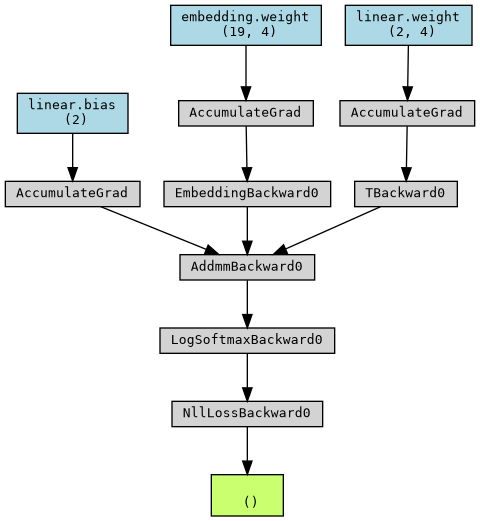

In [10]:
graph = make_dot(loss, params=dict(model.named_parameters()))
graph

`.backward()` só **calcula** os gradientes (preenche `.grad`); quem
**altera** os pesos é o `optimizer.step()`, usando a fórmula
`peso ← peso - lr × grad`. São duas etapas separadas — é fácil assumir que
`backward()` já treina a rede, mas ele não muda peso nenhum sozinho.

# Parte 2: intervenção

Rodando o mesmo passo duas vezes, mudando só o `target` (a "resposta
certa"), com a mesma inicialização de pesos (`one_step` fixa a seed).
Comparamos como isso muda o gradiente.

In [11]:
model_a, loss_a, word_id_a = one_step(target_class=1)
print("\n" + "=" * 60 + "\n")
model_b, loss_b, word_id_b = one_step(target_class=0)

print("\n########## COMPARAÇÃO ##########")
print(f"loss (target=1): {loss_a.item():.4f}")
print(f"loss (target=0): {loss_b.item():.4f}")
print("grad embedding (target=1):", model_a.embedding.weight.grad[word_id_a.item()])
print("grad embedding (target=0):", model_b.embedding.weight.grad[word_id_b.item()])

[Antes do backward]
  embedding.weight.grad: None
  linear.weight.grad: None

[Depois do backward]
  embedding.weight.grad (linha da palavra): tensor([ 0.0579,  0.0440, -0.0561, -0.0195])
  linear.weight.grad:
 tensor([[ 0.0641,  0.6622,  0.5975, -0.1323],
        [-0.0641, -0.6622, -0.5975,  0.1323]])

[Depois do step(), SGD lr=0.1]
  embedding.weight (linha da palavra):
    antes:  tensor([ 0.1198,  1.2377,  1.1168, -0.2473])
    depois: tensor([ 0.1140,  1.2333,  1.1224, -0.2453])
  linear.weight[0]:
    antes:  tensor([ 0.3579,  0.1870, -0.4949, -0.3243])
    depois: tensor([ 0.3515,  0.1207, -0.5546, -0.3111])


[Antes do backward]
  embedding.weight.grad: None
  linear.weight.grad: None

[Depois do backward]
  embedding.weight.grad (linha da palavra): tensor([-0.0503, -0.0383,  0.0487,  0.0169])
  linear.weight.grad:
 tensor([[-0.0557, -0.5755, -0.5193,  0.1150],
        [ 0.0557,  0.5755,  0.5193, -0.1150]])

[Depois do step(), SGD lr=0.1]
  embedding.weight (linha da palavra):


Os gradientes saem com sinal invertido: para cross-entropy com softmax, `∂loss/∂logit_j = prob[j] - 1` se `j` for a classe certa, ou só `prob[j]` caso contrário. Mudar o alvo muda qual logit recebe o `-1`, e isso se propaga pra trás por toda a rede.

# Parte 3: embeddings pré-treinados numa tarefa real

Treinamos CBOW **no corpus de sentimento** (não no `TOY_CORPUS`, senão os
vocabulários não bateriam) e usamos os embeddings resultantes pra
inicializar o classificador, em vez de pesos aleatórios — a mesma ideia
por trás de usar word2vec/GloVe prontos numa tarefa real.

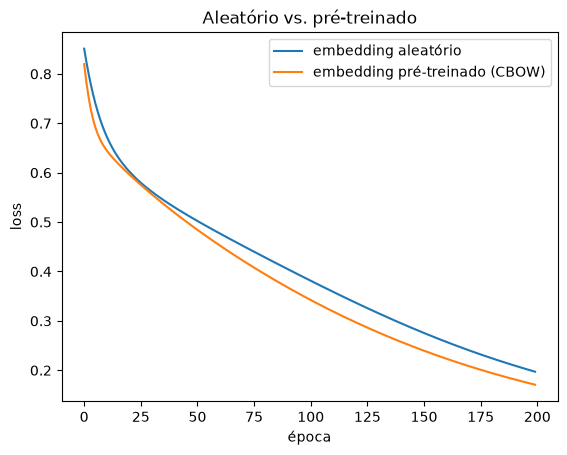

In [12]:
cbow_sentiment_model, _ = train_cbow(corpus=sentiment_sentences, window=1)
pretrained_weights = cbow_sentiment_model.embeddings.weight.detach().clone()

torch.manual_seed(0)
model_random = SentimentClassifier(len(sentiment_vocab), embedding_dim=16)
losses_random = train(model_random, sentiment_tokens, sentiment_offsets, sentiment_labels)

torch.manual_seed(0)
model_pretrained = SentimentClassifier(len(sentiment_vocab), embedding_dim=16)
model_pretrained.embedding.weight.data = pretrained_weights.clone()
losses_pretrained = train(model_pretrained, sentiment_tokens, sentiment_offsets, sentiment_labels)

plt.plot(losses_random, label="embedding aleatório")
plt.plot(losses_pretrained, label="embedding pré-treinado (CBOW)")
plt.xlabel("época")
plt.ylabel("loss")
plt.title("Aleatório vs. pré-treinado")
plt.legend()
plt.show()

A curva pré-treinada fica abaixo da aleatória durante praticamente todo o treino — o embedding já chega sabendo algo sobre como as palavras se relacionam, então o classificador converge mais rápido.